Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v3/FCC/n_cells_1/rho_0.010/lattice.gsd


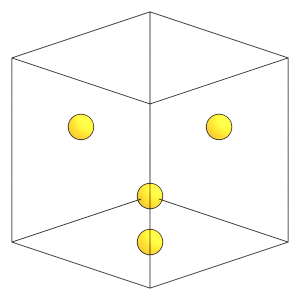

In [6]:
from md_Helpers import lattices
from md_Helpers import visualization as viz

result=lattices.make_lattice_frame(
    n_fcc_cells=1,
    target_rho=.01,
    )

viz.render(result)

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
import fresnel
import ipywidgets as widgets
from IPython.display import Image, display

from md_Helpers import lattices


# Build lattice
result = lattices.make_lattice_frame(
    n_fcc_cells=2,
    target_rho=0.3,
)

positions = np.asarray(result.particles.position)
box = np.asarray(result.configuration.box, dtype=float)
L = max(box[:3])


# Give each distinct z-elevation its own color
z_levels, layer_index = np.unique(
    np.round(positions[:, 2], decimals=8),
    return_inverse=True,
)

color_map = plt.colormaps["turbo"]

layer_colors = color_map(
    np.linspace(0, 1, len(z_levels))
)[:, :3]

particle_colors = layer_colors[layer_index]


# Fresnel setup
device = fresnel.Device()
tracer = fresnel.tracer.Path(
    device=device,
    w=500,
    h=500,
)


def render_lattice(azimuth, elevation, view_scale):
    scene = fresnel.Scene(device)

    particles = fresnel.geometry.Sphere(
        scene,
        N=len(positions),
        radius=0.5,
    )

    particles.position[:] = positions

    particles.material = fresnel.material.Material(
        roughness=0.5,
        primitive_color_mix=1.0,
    )

    particles.color[:] = fresnel.color.linear(
        particle_colors
    )

    particles.outline_width = 0.04

    fresnel.geometry.Box(
        scene,
        box,
        box_radius=0.025,
    )

    az = math.radians(azimuth)
    el = math.radians(elevation)

    camera_distance = 2.5 * L

    camera_position = camera_distance * np.array([
        math.cos(el) * math.cos(az),
        math.cos(el) * math.sin(az),
        math.sin(el),
    ])

    scene.camera = fresnel.camera.Orthographic(
        position=tuple(camera_position),
        look_at=(0, 0, 0),
        up=(0, 0, 1),
        height=L * view_scale,
    )

    scene.lights = fresnel.light.lightbox()
    scene.background_color = (1, 1, 1)
    scene.background_alpha = 1

    image = tracer.sample(
        scene,
        samples=256,
    )

    display(Image(image._repr_png_()))


# Interactive camera controls
azimuth_slider = widgets.FloatSlider(
    value=-65,
    min=-180,
    max=180,
    step=5,
    description="Azimuth",
    continuous_update=False,
)

elevation_slider = widgets.FloatSlider(
    value=10,
    min=-80,
    max=80,
    step=5,
    description="Elevation",
    continuous_update=False,
)

view_scale_slider = widgets.FloatSlider(
    value=1.6,
    min=0.7,
    max=2.5,
    step=0.1,
    description="Zoom out",
    continuous_update=False,
)

output = widgets.interactive_output(
    render_lattice,
    {
        "azimuth": azimuth_slider,
        "elevation": elevation_slider,
        "view_scale": view_scale_slider,
    },
)

display(
    widgets.VBox([
        azimuth_slider,
        elevation_slider,
        view_scale_slider,
        output,
    ])
)

Created new FCC lattice
----------------------------
n_fcc_cells = 2
N = 32
Target rho = 0.3
Actual rho = 0.3
Density error = 0.0
BoxLength = 4.74252440598675
FCC cell size = 2.371262202993375
Saved lattice to:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v3/FCC/n_cells_2/rho_0.300/lattice.gsd


In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
import fresnel
import ipywidgets as widgets
from IPython.display import Image, display

from md_Helpers import lattices


# Lattice settings
n_fcc_cells = 2
target_rho = 0.3


# Build lattice
result = lattices.make_lattice_frame(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
)

positions = np.asarray(
    result.particles.position,
    dtype=float,
)

box = np.asarray(
    result.configuration.box,
    dtype=float,
)

box_lengths = box[:3]
L = max(box_lengths)


# Determine which FCC unit cell contains each particle
cell_size = box_lengths / n_fcc_cells

cell_indices = np.floor(
    (positions + box_lengths / 2) / cell_size
).astype(int)

# Protect against floating-point boundary errors
cell_indices = np.clip(
    cell_indices,
    0,
    n_fcc_cells - 1,
)

# Convert each (x, y, z) cell index into one unique integer
cell_ids = np.ravel_multi_index(
    cell_indices.T,
    dims=(
        n_fcc_cells,
        n_fcc_cells,
        n_fcc_cells,
    ),
)

number_of_cells = n_fcc_cells**3


# Assign a different color to every FCC unit cell
color_map = plt.colormaps["turbo"]

unit_cell_colors = color_map(
    np.linspace(0, 1, number_of_cells)
)[:, :3]

particle_colors = unit_cell_colors[cell_ids]


# Fresnel setup
device = fresnel.Device()

tracer = fresnel.tracer.Path(
    device=device,
    w=500,
    h=500,
)


def render_lattice(azimuth, elevation, view_scale):
    scene = fresnel.Scene(device)

    particles = fresnel.geometry.Sphere(
        scene,
        N=len(positions),
        radius=0.5,
    )

    particles.position[:] = positions

    particles.material = fresnel.material.Material(
        roughness=0.5,
        primitive_color_mix=1.0,
    )

    particles.color[:] = fresnel.color.linear(
        particle_colors
    )

    particles.outline_width = 0.04

    fresnel.geometry.Box(
        scene,
        box,
        box_radius=0.025,
    )

    azimuth_radians = math.radians(azimuth)
    elevation_radians = math.radians(elevation)

    camera_distance = 2.5 * L

    camera_position = camera_distance * np.array([
        math.cos(elevation_radians)
        * math.cos(azimuth_radians),

        math.cos(elevation_radians)
        * math.sin(azimuth_radians),

        math.sin(elevation_radians),
    ])

    scene.camera = fresnel.camera.Orthographic(
        position=tuple(camera_position),
        look_at=(0, 0, 0),
        up=(0, 0, 1),
        height=L * view_scale,
    )

    scene.lights = fresnel.light.lightbox()
    scene.background_color = (1, 1, 1)
    scene.background_alpha = 1

    image = tracer.sample(
        scene,
        samples=256,
    )

    display(Image(image._repr_png_()))


# Interactive camera controls
azimuth_slider = widgets.FloatSlider(
    value=-70,
    min=-180,
    max=180,
    step=5,
    description="Azimuth",
    continuous_update=False,
)

elevation_slider = widgets.FloatSlider(
    value=15,
    min=-80,
    max=80,
    step=5,
    description="Elevation",
    continuous_update=False,
)

view_scale_slider = widgets.FloatSlider(
    value=1.6,
    min=0.7,
    max=2.5,
    step=0.1,
    description="Zoom out",
    continuous_update=False,
)

output = widgets.interactive_output(
    render_lattice,
    {
        "azimuth": azimuth_slider,
        "elevation": elevation_slider,
        "view_scale": view_scale_slider,
    },
)

display(
    widgets.VBox([
        azimuth_slider,
        elevation_slider,
        view_scale_slider,
        output,
    ])
)

Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v3/FCC/n_cells_2/rho_0.300/lattice.gsd
